# Unigram LM Evaluation Results Analysis

This notebook presents the evaluation results of the Unigram Language Model (Dirichlet smoothing) across different values of `mu`.

It showcases:
- the overall performance for each mu value
- the best-performing mu setting
- per-query performance
- comparisons using tables and plots
- comparison with BM25 baseline

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../')

from src.query_data import query

Columns: ['category', 'filename', 'title', 'content']


[nltk_data] Downloading package stopwords to C:\Users\nm-
[nltk_data]     ca\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\nm-
[nltk_data]     ca\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("../data/archive-5/unigram_evaluation_results_with_top5_queries.csv", sep=",")
df.head()

,mu,MAP,Precision@10_overall,nDCG@10_overall,query,AP,Precision@10_query,nDCG@10_query
0,100,0.5758,0.932,0.9459,football team championship win,0.779731,0.9,0.933746
1,100,0.5758,0.932,0.9459,company profits economic growth,0.770770,0.9,0.889954
2,100,0.5758,0.932,0.9459,film awards best actor,0.733410,1.0,1.000000
3,100,0.5758,0.932,0.9459,minister resignation political party,0.718579,1.0,1.000000
4,100,0.5758,0.932,0.9459,tennis player grand slam,0.706043,1.0,1.000000


## Overall Performance by Mu

In [3]:
summary_df = (
    df.groupby("mu", as_index=False)
      .agg({
          "MAP": "first",
          "Precision@10_overall": "first",
          "nDCG@10_overall": "first"
      })
      .sort_values(
          by=["MAP", "nDCG@10_overall", "Precision@10_overall"],
          ascending=False
      )
      .reset_index(drop=True)
)

summary_df

,mu,MAP,Precision@10_overall,nDCG@10_overall
0,500,0.5785,0.920,0.9349
1,1000,0.5778,0.912,0.9171
2,1500,0.5767,0.912,0.9173
3,100,0.5758,0.932,0.9459
4,2000,0.5758,0.916,0.9197
5,2500,0.5750,0.920,0.9191
6,3000,0.5741,0.920,0.9177
7,5000,0.5720,0.928,0.9192


### Best Mu Value

In [4]:
best_result = summary_df.iloc[0]

print("Best Unigram LM Parameter:")
print(f"mu = {int(best_result['mu'])}")
print(f"MAP = {best_result['MAP']:.4f}")
print(f"Precision@10 = {best_result['Precision@10_overall']:.4f}")
print(f"nDCG@10 = {best_result['nDCG@10_overall']:.4f}")

Best Unigram LM Parameter:
mu = 500
MAP = 0.5785
Precision@10 = 0.9200
nDCG@10 = 0.9349


## Performance Table and Visualisation

In [5]:
# Performance table sorted by mu
perf_table = summary_df.sort_values("mu").reset_index(drop=True)
perf_table.columns = ["mu", "MAP", "Precision@10", "nDCG@10"]
display(perf_table)

,mu,MAP,Precision@10,nDCG@10
0,100,0.5758,0.932,0.9459
1,500,0.5785,0.920,0.9349
2,1000,0.5778,0.912,0.9171
3,1500,0.5767,0.912,0.9173
4,2000,0.5758,0.916,0.9197
5,2500,0.5750,0.920,0.9191
6,3000,0.5741,0.920,0.9177
7,5000,0.5720,0.928,0.9192


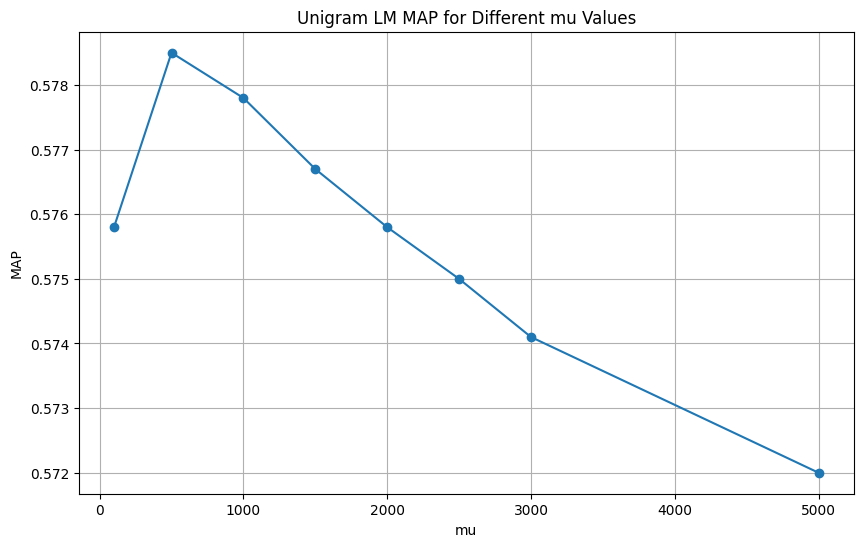

In [6]:
# MAP vs Mu
plot_df = summary_df.sort_values("mu")

plt.figure(figsize=(10, 6))
plt.plot(plot_df["mu"], plot_df["MAP"], marker="o", color="tab:blue")
plt.xlabel("mu")
plt.ylabel("MAP")
plt.title("Unigram LM MAP for Different mu Values")
plt.grid(True)
plt.show()

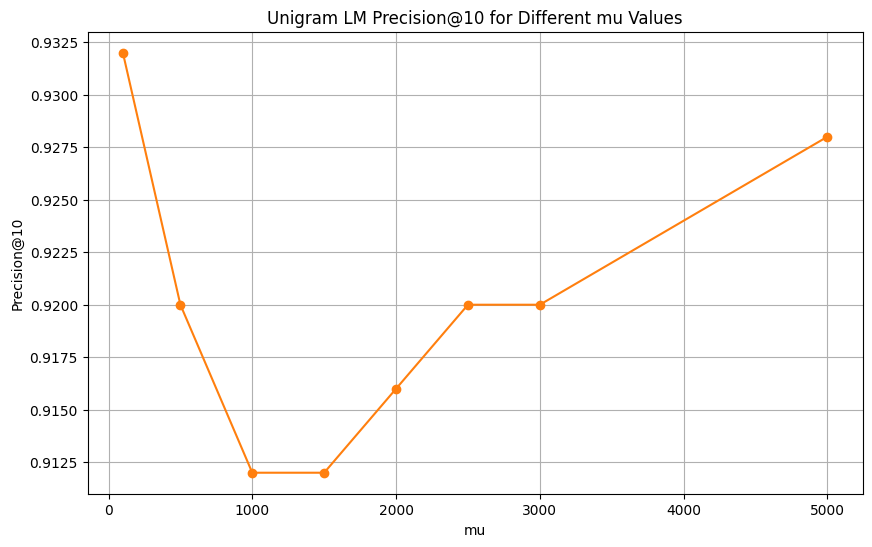

In [7]:
# Precision@10 vs Mu
plt.figure(figsize=(10, 6))
plt.plot(plot_df["mu"], plot_df["Precision@10_overall"], marker="o", color="tab:orange")
plt.xlabel("mu")
plt.ylabel("Precision@10")
plt.title("Unigram LM Precision@10 for Different mu Values")
plt.grid(True)
plt.show()

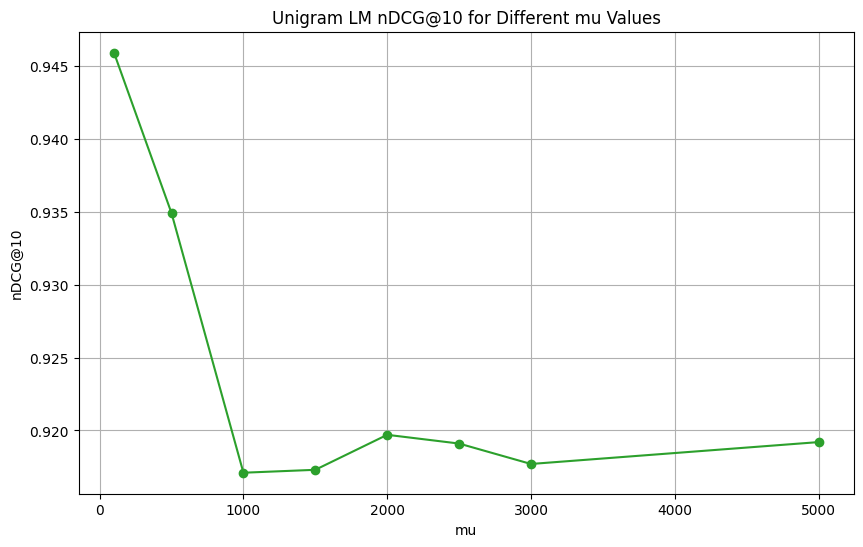

In [8]:
# nDCG@10 vs Mu
plt.figure(figsize=(10, 6))
plt.plot(plot_df["mu"], plot_df["nDCG@10_overall"], marker="o", color="tab:green")
plt.xlabel("mu")
plt.ylabel("nDCG@10")
plt.title("Unigram LM nDCG@10 for Different mu Values")
plt.grid(True)
plt.show()

## Per-Query and Per-Category Analysis

In [9]:
df_with_category = df.merge(
    query[["query", "category"]].drop_duplicates(),
    on="query",
    how="left"
)

query_performance = (
    df_with_category
    .groupby(["query", "category"], as_index=False)
    .agg(
        mean_AP=("AP", "mean"),
        best_AP=("AP", "max"),
        mean_P10=("Precision@10_query", "mean"),
        mean_nDCG10=("nDCG@10_query", "mean")
    )
    .sort_values(
        by=["mean_AP", "mean_nDCG10", "mean_P10"],
        ascending=False
    )
    .reset_index(drop=True)
)

query_performance.insert(0, "rank", query_performance.index + 1)

category_performance = (
    df_with_category
    .groupby("category", as_index=False)
    .agg(
        mean_AP=("AP", "mean"),
        mean_P10=("Precision@10_query", "mean"),
        mean_nDCG10=("nDCG@10_query", "mean")
    )
    .sort_values(by="mean_AP", ascending=False)
    .reset_index(drop=True)
)

best_query_per_category = (
    query_performance
    .sort_values(["category", "mean_AP"], ascending=[True, False])
    .groupby("category", as_index=False)
    .first()
)

print("Top Queries (Ranked Across All Mu Values)")
display(query_performance.round(4))

print("\nCategory Performance (Which Topics Work Best)")
display(category_performance.round(4))

print("\nBest Query per Category")
display(best_query_per_category[[
    "category", "query", "mean_AP", "mean_P10", "mean_nDCG10"
]].round(4))

Top Queries (Ranked Across All Mu Values)


,rank,query,category,mean_AP,best_AP,mean_P10,mean_nDCG10
0,1,company profits economic growth,business,0.7688,0.7749,0.9375,0.9492
1,2,football team championship win,sport,0.7588,0.7797,0.9000,0.8434
2,3,film awards best actor,entertainment,0.7329,0.7373,1.0000,1.0000
3,4,minister resignation political party,politics,0.7090,0.7186,1.0000,1.0000
4,5,tennis player grand slam,sport,0.6989,0.7060,1.0000,1.0000
5,6,government election campaign,politics,0.6842,0.6876,1.0000,1.0000



Category Performance (Which Topics Work Best)


,category,mean_AP,mean_P10,mean_nDCG10
0,business,0.7688,0.9375,0.9492
1,sport,0.7468,0.9200,0.8747
2,entertainment,0.7329,1.0000,1.0000
3,politics,0.6984,1.0000,1.0000



Best Query per Category


,category,query,mean_AP,mean_P10,mean_nDCG10
0,business,company profits economic growth,0.7688,0.9375,0.9492
1,entertainment,film awards best actor,0.7329,1.0000,1.0000
2,politics,minister resignation political party,0.7090,1.0000,1.0000
3,sport,football team championship win,0.7588,0.9000,0.8434


In [10]:
ogdf = pd.read_csv("../data/archive-5/archive (2)/bbc-news-data.csv", sep="\t")
ogdf['document'] = ogdf['title'] + " " + ogdf['content']

category_counts = (
    ogdf["category"]
    .value_counts()
    .reset_index()
)
category_counts.columns = ["category", "doc_count"]

category_summary = (
    df_with_category
    .groupby("category", as_index=False)
    .agg(
        mean_AP=("AP", "mean"),
        best_AP=("AP", "max"),
        mean_P10=("Precision@10_query", "mean"),
        best_P10=("Precision@10_query", "max"),
        mean_nDCG10=("nDCG@10_query", "mean"),
        best_nDCG10=("nDCG@10_query", "max"),
        query_count=("query", "nunique")
    )
    .sort_values(
        by=["mean_AP", "mean_nDCG10", "mean_P10"],
        ascending=False
    )
    .reset_index(drop=True)
)
category_summary = category_summary.merge(category_counts, on="category", how="left")

print("\nCorrelation Between Dataset Size and Performance")
print(category_summary[["doc_count", "mean_AP"]].corr())

print("\nCategory Summary (Overall Performance by Topic)")
display(category_summary.round(4))

print("\nCategory AP Variance")
display(df_with_category.groupby("category")["AP"].std().round(4))


Correlation Between Dataset Size and Performance
           doc_count   mean_AP
doc_count   1.000000  0.711973
mean_AP     0.711973  1.000000

Category Summary (Overall Performance by Topic)


,category,mean_AP,best_AP,mean_P10,best_P10,mean_nDCG10,best_nDCG10,query_count,doc_count
0,business,0.7688,0.7749,0.9375,1.0,0.9492,1.0,1,510
1,sport,0.7468,0.7797,0.9200,1.0,0.8747,1.0,2,511
2,entertainment,0.7329,0.7373,1.0000,1.0,1.0000,1.0,1,386
3,politics,0.6984,0.7186,1.0000,1.0,1.0000,1.0,2,417



Category AP Variance


category
business         0.0039
entertainment    0.0028
politics         0.0140
sport            0.0273
Name: AP, dtype: float64

## Comparison with BM25

In [11]:
# Best BM25 results (k1=1.5, b=1.0)
bm25_best = {
    "Model": "BM25 (k1=1.5, b=1.0)",
    "MAP": 0.5936,
    "Precision@10": 0.936,
    "nDCG@10": 0.9484
}

# Best Unigram LM results
unigram_best = {
    "Model": f"Unigram LM (mu={int(best_result['mu'])})",
    "MAP": best_result["MAP"],
    "Precision@10": best_result["Precision@10_overall"],
    "nDCG@10": best_result["nDCG@10_overall"]
}

comparison_df = pd.DataFrame([bm25_best, unigram_best])
comparison_df = comparison_df.set_index("Model")

print("BM25 vs Unigram LM — Best Configurations")
display(comparison_df.round(4))

BM25 vs Unigram LM — Best Configurations


,MAP,Precision@10,nDCG@10
Model,,,
"BM25 (k1=1.5, b=1.0)",0.5936,0.936,0.9484
Unigram LM (mu=500),0.5785,0.920,0.9349


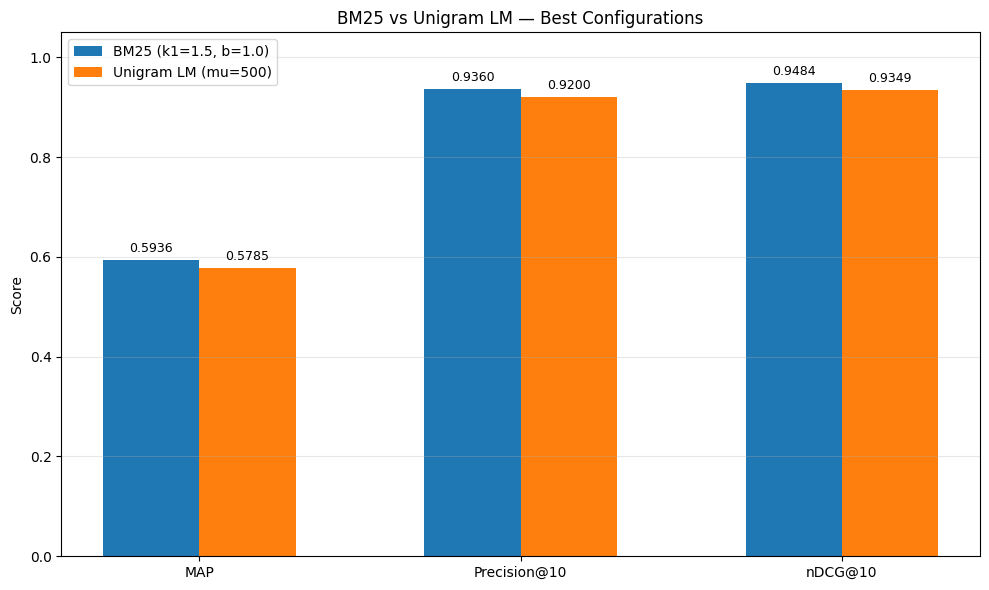

In [12]:
# Side-by-side bar chart
metrics = ["MAP", "Precision@10", "nDCG@10"]
bm25_vals = [bm25_best[m] for m in metrics]
unigram_vals = [unigram_best[m] for m in metrics]

x = range(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], bm25_vals, width, label=bm25_best["Model"])
bars2 = ax.bar([i + width/2 for i in x], unigram_vals, width, label=unigram_best["Model"])

ax.set_ylabel("Score")
ax.set_title("BM25 vs Unigram LM — Best Configurations")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()